In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [19]:
train_data = pd.read_csv(
    "../data/train_data.csv",
    index_col=0,
    parse_dates=True
)

test_data = pd.read_csv(
    "../data/test_data.csv",
    index_col=0,
    parse_dates=True
)

print("Training shape:", train_data.shape)
print("Testing shape:", test_data.shape)

Training shape: (361, 32)
Testing shape: (91, 32)


In [20]:
X_train = train_data.drop(columns=["Target_Up"])
y_train = train_data["Target_Up"]

X_test = test_data.drop(columns=["Target_Up"])
y_test = test_data["Target_Up"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (361, 31)
X_test: (91, 31)
y_train: (361,)
y_test: (91,)


In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling complete!")

Scaling complete!


In [22]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [23]:
y_pred_lr = logistic_model.predict(X_test_scaled)

print("First 20 predictions:")
print(y_pred_lr[:20])

First 20 predictions:
[0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [24]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print(f"Accuracy:  {accuracy_lr:.2%}")
print(f"Precision: {precision_lr:.2%}")
print(f"Recall:    {recall_lr:.2%}")
print(f"F1 Score:  {f1_lr:.2%}")

Accuracy:  49.45%
Precision: 57.14%
Recall:    39.22%
F1 Score:  46.51%


In [25]:
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=[
        "No Increase",
        "Increase"
    ]
))

              precision    recall  f1-score   support

 No Increase       0.45      0.62      0.52        40
    Increase       0.57      0.39      0.47        51

    accuracy                           0.49        91
   macro avg       0.51      0.51      0.49        91
weighted avg       0.52      0.49      0.49        91



In [26]:
cm = confusion_matrix(
    y_test,
    y_pred_lr
)

print(cm)

[[25 15]
 [31 20]]


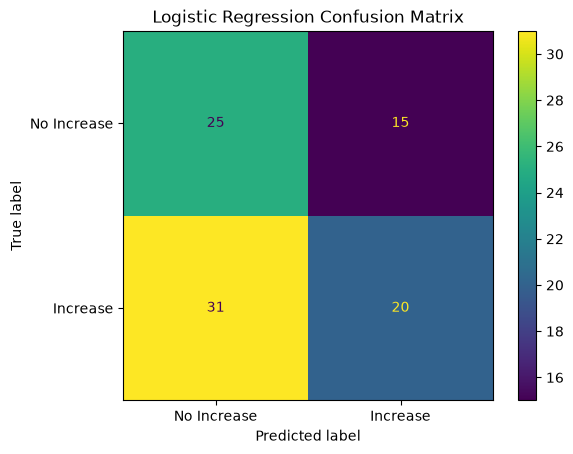

In [27]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Increase", "Increase"]
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [28]:
majority_class = y_train.mode()[0]

baseline_predictions = np.full(
    len(y_test),
    majority_class
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print(f"Baseline Accuracy: {baseline_accuracy:.2%}")
print(f"Logistic Regression Accuracy: {accuracy_lr:.2%}")

Baseline Accuracy: 56.04%
Logistic Regression Accuracy: 49.45%


In [29]:
random_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42,
    class_weight="balanced"
)

random_forest.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [30]:
y_pred_rf = random_forest.predict(X_test)

print("First 20 predictions:")
print(y_pred_rf[:20])

First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [31]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Accuracy:  {accuracy_rf:.2%}")
print(f"Precision: {precision_rf:.2%}")
print(f"Recall:    {recall_rf:.2%}")
print(f"F1 Score:  {f1_rf:.2%}")

Accuracy:  46.15%
Precision: 66.67%
Recall:    7.84%
F1 Score:  14.04%


In [32]:
results = pd.DataFrame({
    "Model": [
        "Majority Baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        baseline_accuracy,
        accuracy_lr,
        accuracy_rf
    ],
    "Precision": [
        np.nan,
        precision_lr,
        precision_rf
    ],
    "Recall": [
        np.nan,
        recall_lr,
        recall_rf
    ],
    "F1 Score": [
        np.nan,
        f1_lr,
        f1_rf
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Majority Baseline,0.560440,NaN,NaN,NaN
1,Logistic Regression,0.494505,0.571429,0.392157,0.465116
2,Random Forest,0.461538,0.666667,0.078431,0.140351


In [33]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
7,Daily_Return,0.052174
19,Volatility_5D,0.051052
25,MACD,0.048081
16,Return_5D,0.044432
17,Return_20D,0.039987
27,MACD_Histogram,0.039532
22,Volume_Ratio,0.038127
30,High_Low_Pct,0.036705
15,Price_to_MA50,0.036244
8,Price_Change,0.036054


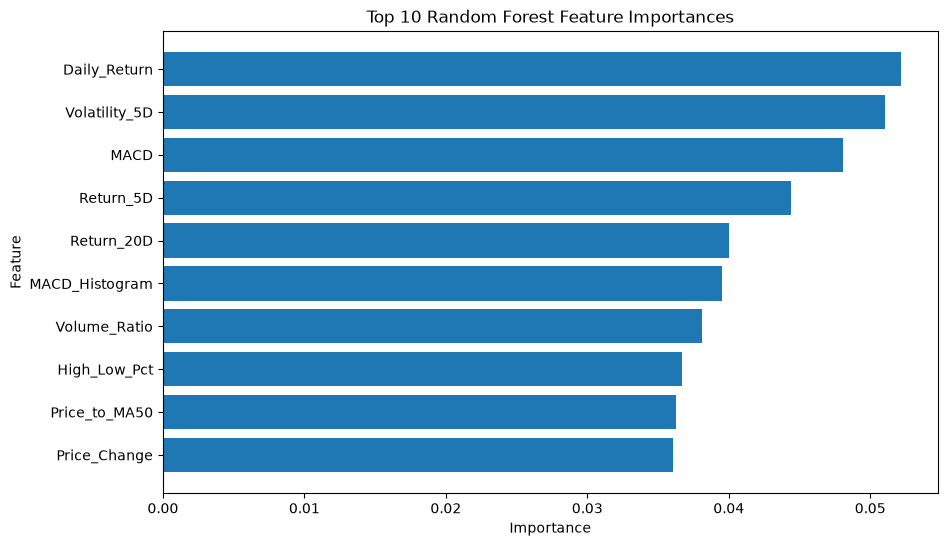

In [34]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [35]:
rf_probabilities = random_forest.predict_proba(X_test)

probability_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_rf,
    "Probability_No_Increase": rf_probabilities[:, 0],
    "Probability_Increase": rf_probabilities[:, 1]
}, index=y_test.index)

probability_results.tail(10)

,Actual,Predicted,Probability_No_Increase,Probability_Increase
Date,,,,
2026-09-02 00:00:00-04:00,1,0,0.678133,0.321867
2026-09-03 00:00:00-04:00,0,0,0.675433,0.324567
2026-09-04 00:00:00-04:00,0,0,0.571179,0.428821
2026-09-08 00:00:00-04:00,0,0,0.679250,0.320750
2026-09-09 00:00:00-04:00,1,0,0.585692,0.414308
2026-09-10 00:00:00-04:00,1,1,0.485062,0.514938
2026-09-11 00:00:00-04:00,1,0,0.518964,0.481036
2026-09-14 00:00:00-04:00,0,0,0.691903,0.308097
2026-09-15 00:00:00-04:00,1,0,0.674067,0.325933


In [36]:
probability_results.sort_values(
    "Probability_Increase",
    ascending=False
).head(10)

,Actual,Predicted,Probability_No_Increase,Probability_Increase
Date,,,,
2026-08-04 00:00:00-04:00,1,1,0.445993,0.554007
2026-08-19 00:00:00-04:00,0,1,0.455331,0.544669
2026-06-26 00:00:00-04:00,0,1,0.456768,0.543232
2026-06-30 00:00:00-04:00,1,1,0.467939,0.532061
2026-09-10 00:00:00-04:00,1,1,0.485062,0.514938
2026-06-17 00:00:00-04:00,1,1,0.488326,0.511674
2026-06-29 00:00:00-04:00,1,0,0.503243,0.496757
2026-07-01 00:00:00-04:00,1,0,0.509904,0.490096
2026-09-11 00:00:00-04:00,1,0,0.518964,0.481036


In [37]:
probability_results.sort_values(
    "Probability_Increase",
    ascending=True
).head(10)

,Actual,Predicted,Probability_No_Increase,Probability_Increase
Date,,,,
2026-07-17 00:00:00-04:00,0,0,0.788072,0.211928
2026-07-27 00:00:00-04:00,1,0,0.772874,0.227126
2026-05-21 00:00:00-04:00,1,0,0.757454,0.242546
2026-07-28 00:00:00-04:00,0,0,0.753499,0.246501
2026-05-11 00:00:00-04:00,1,0,0.752942,0.247058
2026-05-15 00:00:00-04:00,0,0,0.752767,0.247233
2026-05-22 00:00:00-04:00,0,0,0.748866,0.251134
2026-05-27 00:00:00-04:00,1,0,0.747112,0.252888
2026-05-12 00:00:00-04:00,1,0,0.746600,0.253400
